In this notebook, we define a neural network to generate embeddings and use a Random Forest classifier on top of those embeddings, using the fully imputed and pre‑processed dataset $\texttt{df\_ready}$. This NN+RF pipeline serves as the supervised baseline against which we will later compare the contrastive‑learning version of the model, which uses the same architecture. We also evaluate performance across multiple test sizes, allowing us to assess whether contrastive learning provides greater benefits, especially when less data is available.

The accuracy results from the predictions (ROC-AUC and PR-AUC) will be saved on $\texttt{results/5.nn\_rf}$. A summary table is provided at the end of the notebook, reporting the mean ROC‑AUC, PR‑AUC, and accuracy values. These averages are computed across multiple runs using different random states.

# Neural Network + Random forest

In [1]:
import numpy as np
import pandas as pd
import os

from sklearn.model_selection import train_test_split

import gc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from utils import (
    TabularDataset,
    Encoder,
    NNClassifier,
    train_one_epoch,
    evaluate_loss,
    transform_dataset
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

## Load the data and preprocess

In [2]:
path_data = "dataframes/df_ready.csv"
df = pd.read_csv(path_data)

X = df.drop(columns=["VTE"]).values.astype(np.float32)
y = df["VTE"].values.astype(np.int64)

d_init = X.shape[1]
d_init

39

The initial dimension for the NNClassifier (from which the neural network learns through) will be $\texttt{d\_init=39}$.

In [3]:
# Check the class imbalance

vte_counts = df["VTE"].value_counts(dropna=False)
vte_percent = df["VTE"].value_counts(normalize=True, dropna=False) * 100

vte_table = pd.DataFrame({
    "Count": vte_counts,
    "Percent": vte_percent.round(2)
})

print(vte_table)

     Count  Percent
VTE                
0.0    296     75.7
1.0     95     24.3


### Split between training and testing sets

In [4]:
random_state=21
test_size=0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y  # important for imbalanced data
)

In [5]:
# Check % of train and test sets

print("\n=== TRAIN SET ===")
vte_counts_train = pd.Series(y_train).value_counts(dropna=False)
vte_percent_train = pd.Series(y_train).value_counts(normalize=True, dropna=False) * 100

vte_table_train = pd.DataFrame({
    "Count": vte_counts_train,
    "Percent": vte_percent_train.round(2)
})

print(vte_table_train)
print("NaNs:", pd.Series(y_train).isna().sum())

print("\n=== TEST SET ===")
vte_counts_test = pd.Series(y_test).value_counts(dropna=False)
vte_percent_test = pd.Series(y_test).value_counts(normalize=True, dropna=False) * 100

vte_table_test = pd.DataFrame({
    "Count": vte_counts_test,
    "Percent": vte_percent_test.round(2)
})

print(vte_table_test)
print("NaNs:", pd.Series(y_test).isna().sum())


=== TRAIN SET ===
   Count  Percent
0    236    75.64
1     76    24.36
NaNs: 0

=== TEST SET ===
   Count  Percent
0     60    75.95
1     19    24.05
NaNs: 0


### Create the $\texttt{.csv}$ file

In [6]:
results_path = "results/5.nn_rf.csv"

# Check if file exists
if not os.path.exists(results_path):
    print("File not found. Creating new results file...")

    df_results = pd.DataFrame(columns=[
        "model",
        "random_state",
        "test_size",
        "n_epochs",
        "batch_size",
        "learning_rate",
        "weight_decay",
        "ROC-AUC",
        "PR-AUC",
        "Accuracy"
    ])

    df_results.to_csv(results_path, index=False)
else:
    print("Results file already exists.")
    df_results = pd.read_csv(results_path)

df_results.head()

Results file already exists.


,model,random_state,test_size,n_epochs,batch_size,learning_rate,weight_decay,ROC-AUC,PR-AUC,Accuracy
0,NN+RF,42,0.3,50,16,0.0005,0.0001,0.609841,0.390447,0.728814
1,NN+RF,42,0.3,50,16,0.0005,0.0001,0.600542,0.363773,0.771186
2,NN+RF,42,0.3,50,16,0.0005,0.0001,0.633088,0.385839,0.754237
3,NN+RF,42,0.3,50,16,0.0005,0.0001,0.653429,0.446422,0.728814
4,NN+RF,42,0.3,50,16,0.0005,0.0001,0.660209,0.429517,0.796610


## Model Variables

In [7]:
BATCH_SIZE = 16 # try 16/32
LR = 1e-4
N_EPOCHS = 50
weight_decay = 1e-4 # try 1e-4/1e-8

model_name = "NN+RF"

#### Device and empty cache

In [8]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using {device} device")

gc.collect()
if device == "mps":
    torch.mps.empty_cache()
if device == "cuda":
    torch.cuda.empty_cache()

Using cpu device


# Training the model

### Creating PyTorch datasets and dataloaders

In [9]:
# These lines convert the NumPy splits into PyTorch datasets and then 
# into DataLoaders that efficiently feed mini‑batches to your neural network.

# Two PyTorch Datasets (train + test)
train_dataset = TabularDataset(X_train, y_train)
test_dataset = TabularDataset(X_test, y_test)

# Two DataLoaders that will feed mini‑batches to the neural network during training and evaluation
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Initializing the neural network

In [10]:
# Initializes your neural network model
d_init = X_train.shape[1]
model = NNClassifier(d_init=d_init, d_emb=16).to(device)

### Defining loss and optimizer

In [11]:
# For imbalanced data, use pos_weight in BCEWithLogitsLoss
pos_weight_value = (len(y_train) - y_train.sum()) / y_train.sum()  # N_neg / N_pos
pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32).to(device)

# Defines the loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Defines the optimizer (AdamW, same as in contrastive model)
optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=weight_decay
    )

## Training the neural Network

In [12]:
for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_loss(model, test_loader, criterion, device)
    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 1.0670 | Val Loss: 1.0586
Epoch 002 | Train Loss: 1.0620 | Val Loss: 1.0554
Epoch 003 | Train Loss: 1.0588 | Val Loss: 1.0520
Epoch 004 | Train Loss: 1.0555 | Val Loss: 1.0502
Epoch 005 | Train Loss: 1.0535 | Val Loss: 1.0487
Epoch 006 | Train Loss: 1.0519 | Val Loss: 1.0472
Epoch 007 | Train Loss: 1.0506 | Val Loss: 1.0464
Epoch 008 | Train Loss: 1.0498 | Val Loss: 1.0459
Epoch 009 | Train Loss: 1.0495 | Val Loss: 1.0455
Epoch 010 | Train Loss: 1.0492 | Val Loss: 1.0452
Epoch 011 | Train Loss: 1.0490 | Val Loss: 1.0453
Epoch 012 | Train Loss: 1.0485 | Val Loss: 1.0451
Epoch 013 | Train Loss: 1.0482 | Val Loss: 1.0449
Epoch 014 | Train Loss: 1.0483 | Val Loss: 1.0447
Epoch 015 | Train Loss: 1.0482 | Val Loss: 1.0447
Epoch 016 | Train Loss: 1.0479 | Val Loss: 1.0446
Epoch 017 | Train Loss: 1.0479 | Val Loss: 1.0446
Epoch 018 | Train Loss: 1.0476 | Val Loss: 1.0445
Epoch 019 | Train Loss: 1.0476 | Val Loss: 1.0445
Epoch 020 | Train Loss: 1.0475 | Val Loss: 1.0444


### Extract embeddings for train and test

In [13]:
model.eval()

# Transform the original dataset into embeddings 
X_t, y_t = transform_dataset(model, train_loader, device)
X_ts, y_ts = transform_dataset(model, test_loader, device)

## Training the RandomForest classifier on embeddings

In [14]:
clf = RandomForestClassifier(
    n_estimators=101,
    max_depth=None,
    min_samples_split=2,
    random_state=random_state,
    class_weight="balanced"  # important for imbalanced VTE
)

clf.fit(X_t, y_t)  

yhat = clf.predict(X_ts)
y_proba = clf.predict_proba(X_ts)[:, 1]

## ROC, Precision-Recall curves and accuracy

In [15]:
roc_auc = roc_auc_score(y_ts, y_proba)
pr_auc = average_precision_score(y_ts, y_proba)
acc = accuracy_score(y_ts, yhat)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Accuracy:", acc)

ROC-AUC: 0.47412280701754383
PR-AUC: 0.26783617490404615
Accuracy: 0.7088607594936709


In [16]:
print(classification_report(y_ts, yhat))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82        60
           1       0.30      0.16      0.21        19

    accuracy                           0.71        79
   macro avg       0.53      0.52      0.51        79
weighted avg       0.66      0.71      0.67        79



<Figure size 600x500 with 0 Axes>

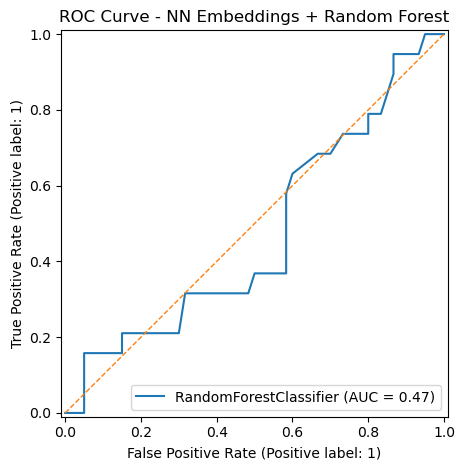

In [17]:
# --- ROC CURVE ---
plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(clf, X_ts, y_ts)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title("ROC Curve - NN Embeddings + Random Forest")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

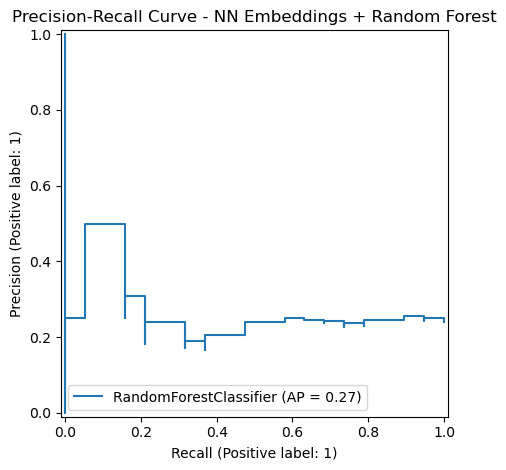

In [18]:
# --- PRECISION-RECALL CURVE ---
plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_estimator(clf, X_ts, y_ts)
plt.title("Precision-Recall Curve - NN Embeddings + Random Forest")
plt.tight_layout()
plt.show()

## Save results to the $\texttt{.csv}$

In [19]:
df_results.loc[len(df_results)] = [
    model_name,
    random_state,
    test_size,
    N_EPOCHS,
    BATCH_SIZE,
    LR,
    weight_decay,
    roc_auc,
    pr_auc,
    acc
]

df_results.to_csv(results_path, index=False)
df_results.tail()

,model,random_state,test_size,n_epochs,batch_size,learning_rate,weight_decay,ROC-AUC,PR-AUC,Accuracy
266,NN+RF,5,0.2,50,16,0.0001,0.0001,0.588158,0.303389,0.734177
267,NN+RF,5,0.2,50,16,0.0001,0.0001,0.643421,0.372833,0.759494
268,NN+RF,21,0.2,50,16,0.0001,0.0001,0.542105,0.258925,0.670886
269,NN+RF,21,0.2,50,16,0.0001,0.0001,0.579825,0.321308,0.746835
270,NN+RF,21,0.2,50,16,0.0001,0.0001,0.474123,0.267836,0.708861


Before trying different test sizes, I tried four different combinations of $\texttt{batch\_size}$ and $\texttt{weight\_decay}$, so I could see, which parameters were apparently best. The result of this check was $\texttt{batch\_size}=16$ and $\texttt{weight\_decay}=1e-4$. After this, the rest of the results are computed for different sizes of the testing set.

In [20]:
summary = (
    df_results
    .query("random_state == 42 and test_size == 0.3")
    .groupby(["batch_size", "weight_decay"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary

,batch_size,weight_decay,ROC-AUC,PR-AUC,Accuracy
0,16,1.000000e-08,0.592755,0.372785,0.750847
1,16,1.000000e-04,0.631422,0.403200,0.755932
2,32,1.000000e-08,0.595893,0.383854,0.747458
3,32,1.000000e-04,0.588260,0.384888,0.742373


# Summary table

In [21]:
summary = (
    df_results
    .query("batch_size == 16 and weight_decay == 1e-4")
    .groupby("test_size")[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary

,test_size,ROC-AUC,PR-AUC,Accuracy
0,0.20,0.579130,0.352898,0.747363
1,0.30,0.573843,0.336671,0.744280
2,0.33,0.559431,0.329578,0.741346
3,0.50,0.536315,0.297068,0.723639
4,0.60,0.527297,0.280519,0.726950
5,0.66,0.520990,0.275647,0.734073
6,0.70,0.518825,0.273548,0.728254
7,0.75,0.529743,0.281156,0.734694
8,0.80,0.527515,0.279516,0.730298
9,0.90,0.499672,0.249409,0.703717
